Processing JSON Sounding: RAP_1778781600_3777-9997.json
Lapse rate =  8.263388755181458
Skew-T Plot saved successfully as RAP_JSON_SkewT_Plot.png
Theta-E Profile saved successfully as RAP_JSON_ThetaE_Plot.png


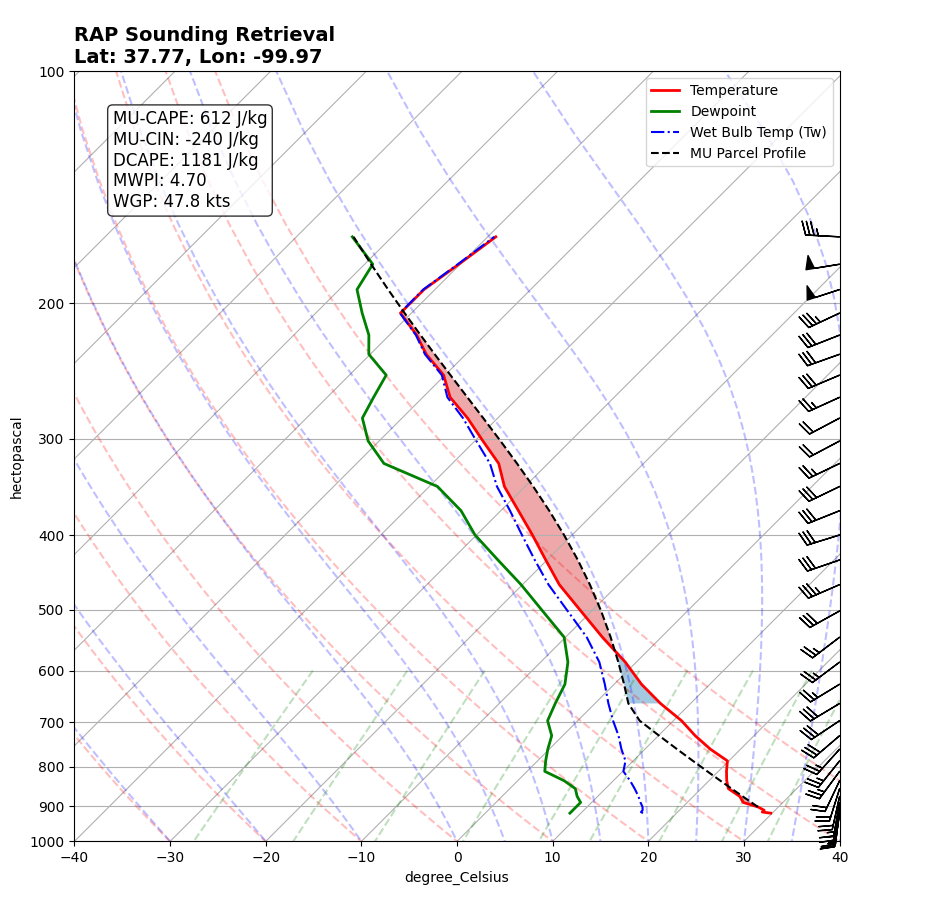

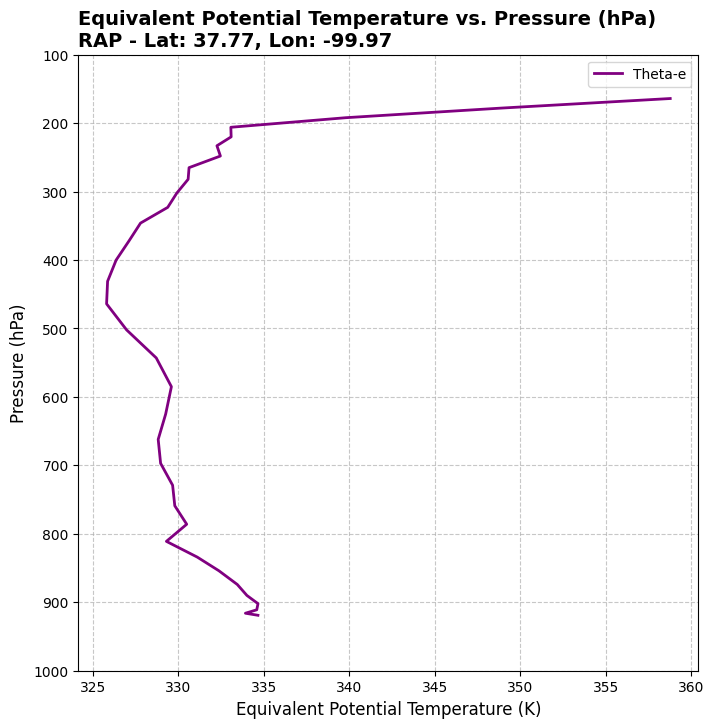

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

def get_standard_height_km(pressure_hpa):
    """
    Interpolates geometric height (km) for a given pressure array 
    based on the 1976 US Standard Atmosphere Table.
    """
    # Standard Atmosphere Table (Z in km, P in hPa)
    std_z = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28, 30])
    std_p = np.array([1013.25, 898.76, 795.01, 701.21, 616.60, 540.48, 472.17, 411.05, 356.51, 308.00, 264.99, 
                      227.00, 193.99, 165.79, 141.70, 121.11, 103.52, 88.49, 75.65, 64.67, 55.29, 40.47, 29.71, 
                      21.88, 16.16, 11.97])
    
    # np.interp expects x-coordinates to be monotonically increasing.
    # We use the natural log of pressure and reverse the arrays.
    log_p = np.log(std_p[::-1])
    z_rev = std_z[::-1]
    
    log_target_p = np.log(pressure_hpa)
    height_km = np.interp(log_target_p, log_p, z_rev)
    return height_km

def calculate_dcape(p, T, Td):
    """Calculates DCAPE (Downdraft CAPE) by finding min Theta-e."""
    try:
        theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
        
        sfc_p = p[0]
        search_layer_mask = p >= (sfc_p - 400 * units.hPa)
        min_thetae_idx = np.argmin(theta_e[search_layer_mask])
        
        p_origin = p[search_layer_mask][min_thetae_idx]
        T_origin = T[search_layer_mask][min_thetae_idx]
        Td_origin = Td[search_layer_mask][min_thetae_idx]
        
        wb_origin = mpcalc.wet_bulb_temperature(p_origin, T_origin, Td_origin)
        descending_p = p[p >= p_origin]
        
        downdraft_profile = mpcalc.moist_lapse(descending_p, wb_origin, reference_pressure=p_origin)
        env_T = T[p >= p_origin]
        
        delta_p = np.abs(np.diff(descending_p.m)) * units.hPa
        T_diff = (env_T.to('kelvin') - downdraft_profile.to('kelvin'))[:-1]
        Rd = 287.058 * units('J / (kg * K)')
        
        dcape_integral = np.sum(Rd * T_diff * (delta_p / descending_p[:-1]))
        return np.max([0, dcape_integral.m]) * units('J/kg')
    except Exception as e:
        print(f"Error calculating DCAPE: {e}")
        return 0 * units('J/kg')

def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
    """Calculates the Microburst Windspeed Potential Index (MWPI) and Wind Gust Potential (WGP)."""
    gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
    print("Lapse rate = ", gamma)
    DD_upper = T_upper - TD_upper
    DD_lower = T_lower - TD_lower
    DDD = DD_lower - DD_upper
    
    MWPI_val = (CAPE/1000) + (gamma/5) + (DDD/5)
    WGP = (0.35435365777 * (MWPI_val**2)) + (1.2959855 * MWPI_val) + 33.8176788
    
    return MWPI_val, WGP

def plot_rap_json_sounding(file_path):
    print(f"Processing JSON Sounding: {file_path}")
    
    # 1. Read JSON Data
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Extract arrays and metadata (dynamically check for pressure key)
    press_key = 'pressures' if 'pressures' in data else 'temp_pressures'
    
    p = np.array(data[press_key]) * units.hPa
    T = (np.array(data['temperatures']) * units.K).to('degC')
    Td = (np.array(data['dewpoints']) * units.K).to('degC')
    
    # Extract wind components (assuming standard model output in knots)
    u = np.array(data['uwinds']) * units.knots
    v = np.array(data['vwinds']) * units.knots
    
    model_name = data.get('source', 'RAP Model')
    lat_val = data.get('lat', 0.0)
    lon_val = data.get('lon', 0.0)
    
    # 2. Interpolate Geometric Height (km) array
    height_km = get_standard_height_km(p.m) * units.km
    
    # 3. Perform Thermodynamic Calculations
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
    mu_p, mu_t, mu_td, mu_idx = mpcalc.most_unstable_parcel(p, T, Td)
    parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')
    
    dcape = calculate_dcape(p, T, Td)
    Tw = mpcalc.wet_bulb_temperature(p, T, Td)
    theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
    
    # --- MWPI Calculation Setup ---
    p_m = p.m
    sort_idx = np.argsort(p_m)
    p_sorted = p_m[sort_idx]
    
    def log_interp_level(target_p, val_arr):
        return np.interp(np.log(target_p), np.log(p_sorted), val_arr[sort_idx])

    P_level_upper = max(500.0, p_sorted[0])
    P_level_lower = min(850.0, p_sorted[-1])
    
    T_upper = log_interp_level(P_level_upper, T.m)
    T_lower = log_interp_level(P_level_lower, T.m)
    TD_upper = log_interp_level(P_level_upper, Td.m)
    TD_lower = log_interp_level(P_level_lower, Td.m)
    
    Z_upper = log_interp_level(P_level_upper, height_km.m)
    Z_lower = log_interp_level(P_level_lower, height_km.m)
    
    mwpi_val, wgp_val = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, 
                             T_upper, T_lower, TD_upper, TD_lower, mucape.m)

    # ==========================================
    # FIGURE 1: SKEW-T LOG-P DIAGRAM
    # ==========================================
    fig1 = plt.figure(figsize=(10, 10))
    skew = SkewT(fig1, rotation=45)
    
    # Plot environmental profiles (Including Tw)
    skew.plot(p, T, 'r', linewidth=2, label='Temperature')
    skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')
    skew.plot(p, Tw, 'b', linestyle='-.', linewidth=1.5, label='Wet Bulb Temp (Tw)')
    
    # Plot Parcel Path and Shade
    skew.plot(p[mu_idx:], parcel_prof, 'k', linestyle='--', linewidth=1.5, label='MU Parcel Profile')
    skew.shade_cape(p[mu_idx:], T[mu_idx:], parcel_prof)
    skew.shade_cin(p[mu_idx:], T[mu_idx:], parcel_prof, Td[mu_idx:])
    
    # Plot wind barbs (Decimate using interval to avoid vertical overlap)
    interval = max(1, len(p) // 30)  
    skew.plot_barbs(p[::interval], u[::interval], v[::interval])
    
    # Standard Skew-T background lines
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    
    skew.ax.set_ylim(1000, 100)
    skew.ax.set_xlim(-40, 40)
    
    plt.title(f'{model_name} Sounding Retrieval\nLat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
              fontsize=14, fontweight='bold', loc='left')
    
    param_text = f"MU-CAPE: {mucape:~P.0f}\nMU-CIN: {mucin:~P.0f}\nDCAPE: {dcape:~P.0f}\nMWPI: {mwpi_val:.2f}\nWGP: {wgp_val:.1f} kts"
    skew.ax.text(0.05, 0.95, param_text, transform=skew.ax.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    skew.ax.legend(loc='upper right')
    
    output_filename1 = 'RAP_JSON_SkewT_Plot.png'
    plt.savefig(output_filename1, bbox_inches='tight', dpi=150)
    print(f"Skew-T Plot saved successfully as {output_filename1}")
    
    # ==========================================
    # FIGURE 2: THETA-E VS PRESSURE DIAGRAM
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.plot(theta_e, p, color='purple', linewidth=2, label='Theta-e')
    
    ax2.set_ylim(1000, 100)
    ax2.set_yscale('linear') 
    
    ax2.set_xlabel('Equivalent Potential Temperature (K)', fontsize=12)
    ax2.set_ylabel('Pressure (hPa)', fontsize=12)
    ax2.set_title(f'Equivalent Potential Temperature vs. Pressure (hPa)\n{model_name} - Lat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
                  fontsize=14, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')
    
    output_filename2 = 'RAP_JSON_ThetaE_Plot.png'
    plt.savefig(output_filename2, bbox_inches='tight', dpi=150)
    print(f"Theta-E Profile saved successfully as {output_filename2}")
    
    plt.show()

if __name__ == "__main__":
    file_name = "RAP_1778781600_3777-9997.json"
    plot_rap_json_sounding(file_name)

Processing JSON Sounding: RAP_1778785200_3704-10097.json
Lapse rate =  9.911820177804891
Skew-T Plot saved successfully as RAP_JSON_SkewT_Plot.png
Theta-E Profile saved successfully as RAP_JSON_ThetaE_Plot.png


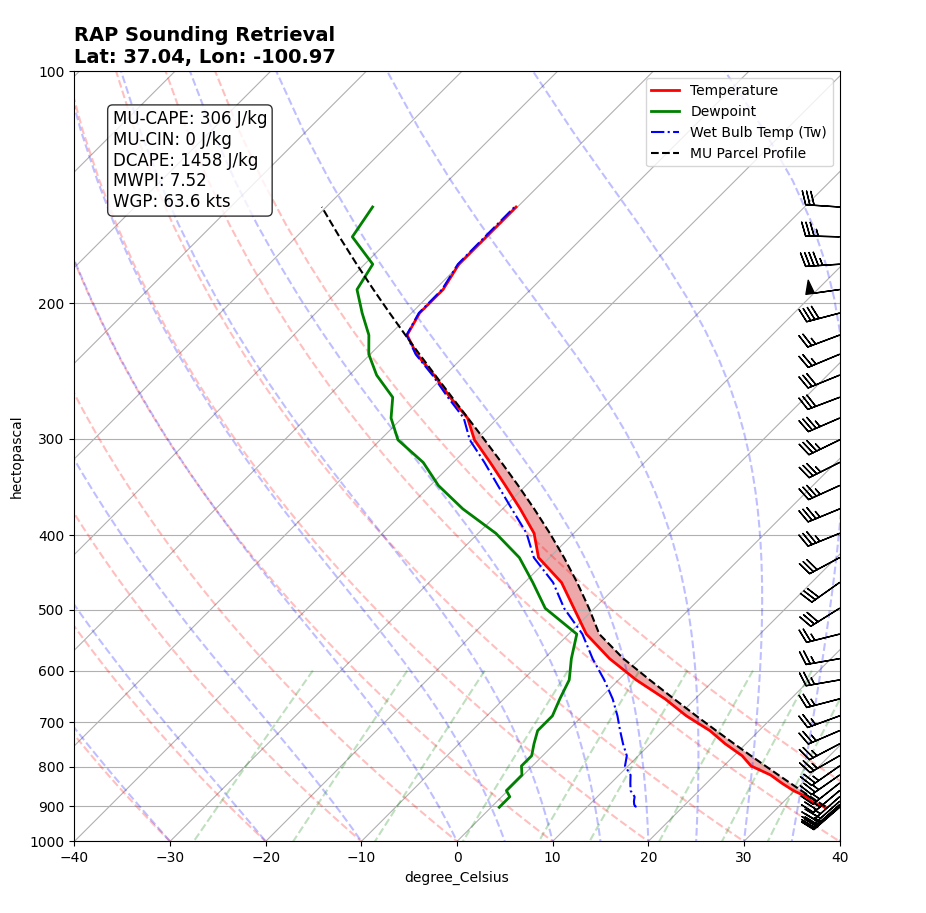

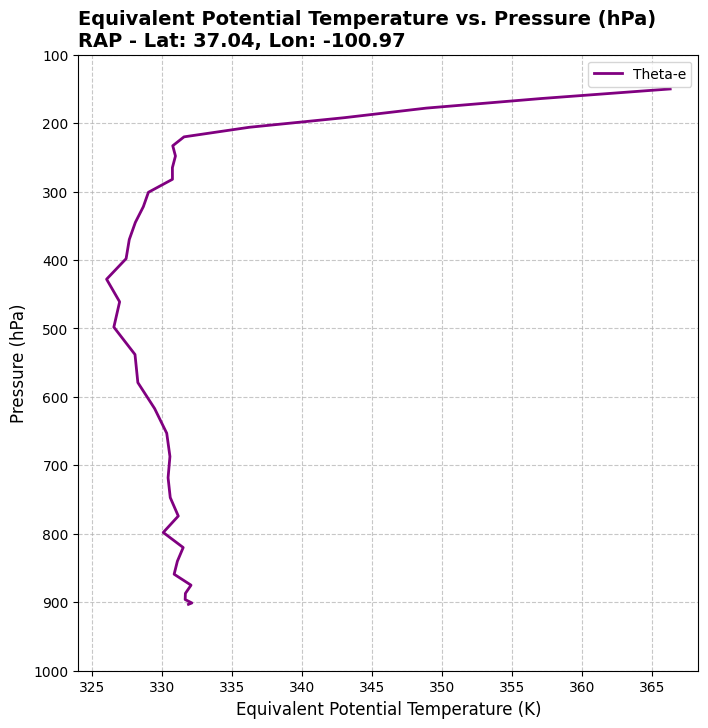

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

def get_standard_height_km(pressure_hpa):
    """
    Interpolates geometric height (km) for a given pressure array 
    based on the 1976 US Standard Atmosphere Table.
    """
    # Standard Atmosphere Table (Z in km, P in hPa)
    std_z = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28, 30])
    std_p = np.array([1013.25, 898.76, 795.01, 701.21, 616.60, 540.48, 472.17, 411.05, 356.51, 308.00, 264.99, 
                      227.00, 193.99, 165.79, 141.70, 121.11, 103.52, 88.49, 75.65, 64.67, 55.29, 40.47, 29.71, 
                      21.88, 16.16, 11.97])
    
    # np.interp expects x-coordinates to be monotonically increasing.
    # We use the natural log of pressure and reverse the arrays.
    log_p = np.log(std_p[::-1])
    z_rev = std_z[::-1]
    
    log_target_p = np.log(pressure_hpa)
    height_km = np.interp(log_target_p, log_p, z_rev)
    return height_km

def calculate_dcape(p, T, Td):
    """Calculates DCAPE (Downdraft CAPE) by finding min Theta-e."""
    try:
        theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
        
        sfc_p = p[0]
        search_layer_mask = p >= (sfc_p - 400 * units.hPa)
        min_thetae_idx = np.argmin(theta_e[search_layer_mask])
        
        p_origin = p[search_layer_mask][min_thetae_idx]
        T_origin = T[search_layer_mask][min_thetae_idx]
        Td_origin = Td[search_layer_mask][min_thetae_idx]
        
        wb_origin = mpcalc.wet_bulb_temperature(p_origin, T_origin, Td_origin)
        descending_p = p[p >= p_origin]
        
        downdraft_profile = mpcalc.moist_lapse(descending_p, wb_origin, reference_pressure=p_origin)
        env_T = T[p >= p_origin]
        
        delta_p = np.abs(np.diff(descending_p.m)) * units.hPa
        T_diff = (env_T.to('kelvin') - downdraft_profile.to('kelvin'))[:-1]
        Rd = 287.058 * units('J / (kg * K)')
        
        dcape_integral = np.sum(Rd * T_diff * (delta_p / descending_p[:-1]))
        return np.max([0, dcape_integral.m]) * units('J/kg')
    except Exception as e:
        print(f"Error calculating DCAPE: {e}")
        return 0 * units('J/kg')

def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
    """Calculates the Microburst Windspeed Potential Index (MWPI) and Wind Gust Potential (WGP)."""
    gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
    print("Lapse rate = ", gamma)
    DD_upper = T_upper - TD_upper
    DD_lower = T_lower - TD_lower
    DDD = DD_lower - DD_upper
    
    MWPI_val = (CAPE/1000) + (gamma/5) + (DDD/5)
    WGP = (0.35435365777 * (MWPI_val**2)) + (1.2959855 * MWPI_val) + 33.8176788
    
    return MWPI_val, WGP

def plot_rap_json_sounding(file_path):
    print(f"Processing JSON Sounding: {file_path}")
    
    # 1. Read JSON Data
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Extract arrays and metadata (dynamically check for pressure key)
    press_key = 'pressures' if 'pressures' in data else 'temp_pressures'
    
    p = np.array(data[press_key]) * units.hPa
    T = (np.array(data['temperatures']) * units.K).to('degC')
    Td = (np.array(data['dewpoints']) * units.K).to('degC')
    
    # Extract wind components (assuming standard model output in knots)
    u = np.array(data['uwinds']) * units.knots
    v = np.array(data['vwinds']) * units.knots
    
    model_name = data.get('source', 'RAP Model')
    lat_val = data.get('lat', 0.0)
    lon_val = data.get('lon', 0.0)
    
    # 2. Interpolate Geometric Height (km) array
    height_km = get_standard_height_km(p.m) * units.km
    
    # 3. Perform Thermodynamic Calculations
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
    mu_p, mu_t, mu_td, mu_idx = mpcalc.most_unstable_parcel(p, T, Td)
    parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')
    
    dcape = calculate_dcape(p, T, Td)
    Tw = mpcalc.wet_bulb_temperature(p, T, Td)
    theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
    
    # --- MWPI Calculation Setup ---
    p_m = p.m
    sort_idx = np.argsort(p_m)
    p_sorted = p_m[sort_idx]
    
    def log_interp_level(target_p, val_arr):
        return np.interp(np.log(target_p), np.log(p_sorted), val_arr[sort_idx])

    P_level_upper = max(500.0, p_sorted[0])
    P_level_lower = min(850.0, p_sorted[-1])
    
    T_upper = log_interp_level(P_level_upper, T.m)
    T_lower = log_interp_level(P_level_lower, T.m)
    TD_upper = log_interp_level(P_level_upper, Td.m)
    TD_lower = log_interp_level(P_level_lower, Td.m)
    
    Z_upper = log_interp_level(P_level_upper, height_km.m)
    Z_lower = log_interp_level(P_level_lower, height_km.m)
    
    mwpi_val, wgp_val = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, 
                             T_upper, T_lower, TD_upper, TD_lower, mucape.m)

    # ==========================================
    # FIGURE 1: SKEW-T LOG-P DIAGRAM
    # ==========================================
    fig1 = plt.figure(figsize=(10, 10))
    skew = SkewT(fig1, rotation=45)
    
    # Plot environmental profiles (Including Tw)
    skew.plot(p, T, 'r', linewidth=2, label='Temperature')
    skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')
    skew.plot(p, Tw, 'b', linestyle='-.', linewidth=1.5, label='Wet Bulb Temp (Tw)')
    
    # Plot Parcel Path and Shade
    skew.plot(p[mu_idx:], parcel_prof, 'k', linestyle='--', linewidth=1.5, label='MU Parcel Profile')
    skew.shade_cape(p[mu_idx:], T[mu_idx:], parcel_prof)
    skew.shade_cin(p[mu_idx:], T[mu_idx:], parcel_prof, Td[mu_idx:])
    
    # Plot wind barbs (Decimate using interval to avoid vertical overlap)
    interval = max(1, len(p) // 30)  
    skew.plot_barbs(p[::interval], u[::interval], v[::interval])
    
    # Standard Skew-T background lines
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    
    skew.ax.set_ylim(1000, 100)
    skew.ax.set_xlim(-40, 40)
    
    plt.title(f'{model_name} Sounding Retrieval\nLat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
              fontsize=14, fontweight='bold', loc='left')
    
    param_text = f"MU-CAPE: {mucape:~P.0f}\nMU-CIN: {mucin:~P.0f}\nDCAPE: {dcape:~P.0f}\nMWPI: {mwpi_val:.2f}\nWGP: {wgp_val:.1f} kts"
    skew.ax.text(0.05, 0.95, param_text, transform=skew.ax.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    skew.ax.legend(loc='upper right')
    
    output_filename1 = 'RAP_JSON_SkewT_Plot.png'
    plt.savefig(output_filename1, bbox_inches='tight', dpi=150)
    print(f"Skew-T Plot saved successfully as {output_filename1}")
    
    # ==========================================
    # FIGURE 2: THETA-E VS PRESSURE DIAGRAM
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.plot(theta_e, p, color='purple', linewidth=2, label='Theta-e')
    
    ax2.set_ylim(1000, 100)
    ax2.set_yscale('linear') 
    
    ax2.set_xlabel('Equivalent Potential Temperature (K)', fontsize=12)
    ax2.set_ylabel('Pressure (hPa)', fontsize=12)
    ax2.set_title(f'Equivalent Potential Temperature vs. Pressure (hPa)\n{model_name} - Lat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
                  fontsize=14, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')
    
    output_filename2 = 'RAP_JSON_ThetaE_Plot.png'
    plt.savefig(output_filename2, bbox_inches='tight', dpi=150)
    print(f"Theta-E Profile saved successfully as {output_filename2}")
    
    plt.show()

if __name__ == "__main__":
    file_name = "RAP_1778785200_3704-10097.json"
    plot_rap_json_sounding(file_name)

Processing RAOB JSON Sounding: Radiosonde_1778781600_3776-9997.json


C:\Users\ken.pryor\AppData\Local\Temp\1\ipykernel_5924\1384050413.py:106: UserWarning: Duplicate pressure(s) [100.0 197.0] hPa provided. Output profile includes duplicate temperatures as a result.
  mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
C:\Users\ken.pryor\AppData\Local\Temp\1\ipykernel_5924\1384050413.py:108: UserWarning: Duplicate pressure(s) [100.0 197.0] hPa provided. Output profile includes duplicate temperatures as a result.
  parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')


Error calculating DCAPE: Values in `t_eval` are not properly sorted.
Skew-T Plot saved successfully as RAOB_JSON_SkewT_Plot.png
Theta-E Profile saved successfully as RAOB_JSON_ThetaE_Plot.png


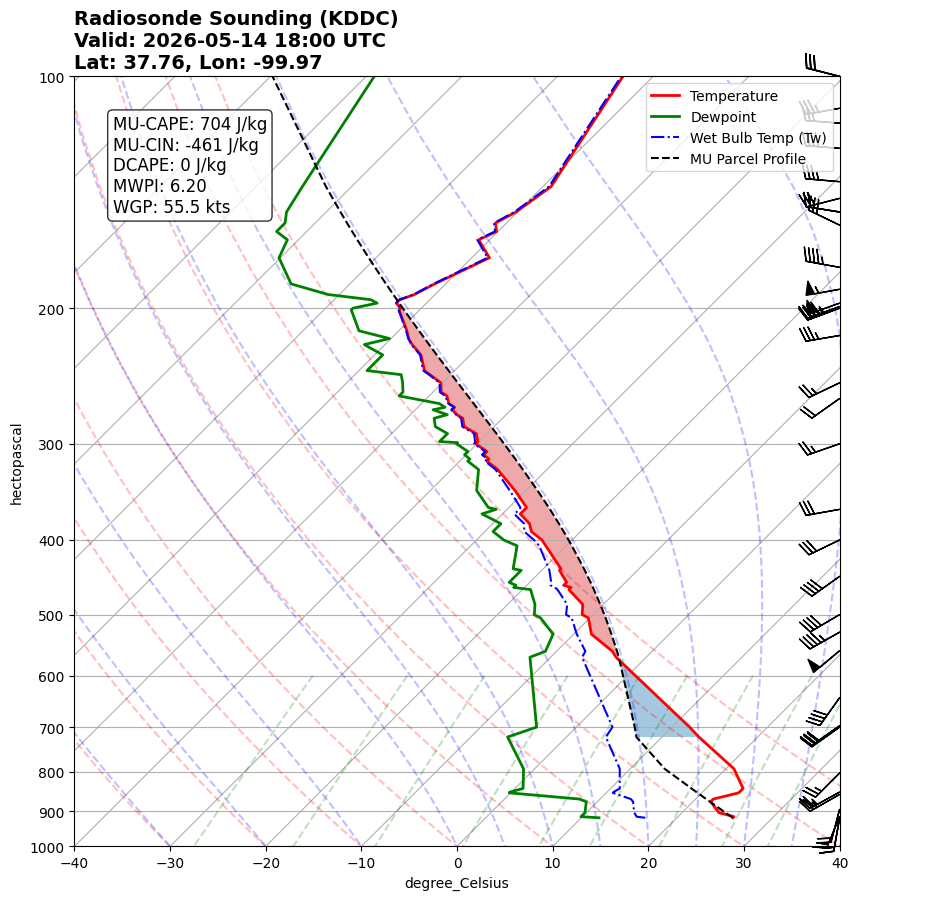

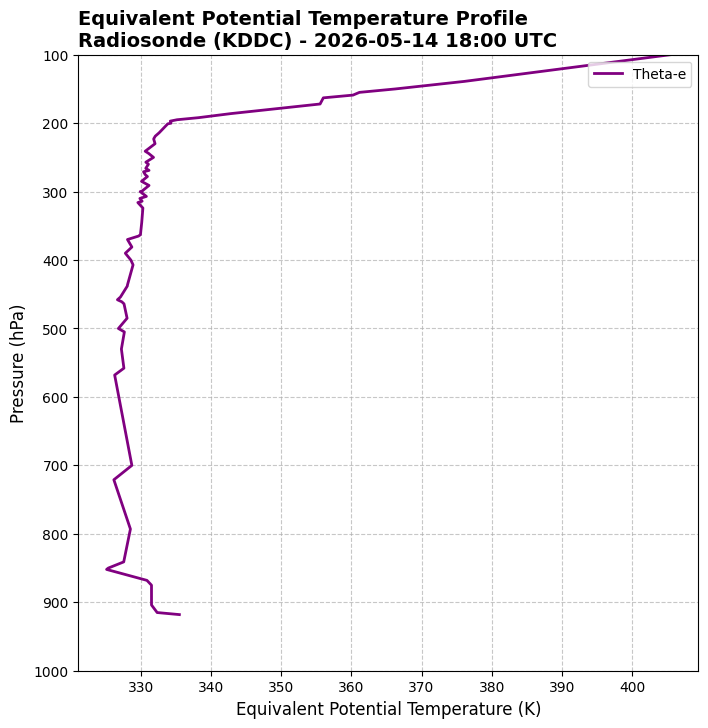

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units
from datetime import datetime, timezone

def get_standard_height_km(pressure_hpa):
    """
    Interpolates geometric height (km) for a given pressure array 
    based on the 1976 US Standard Atmosphere Table.
    """
    # Standard Atmosphere Table (Z in km, P in hPa)
    std_z = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28, 30])
    std_p = np.array([1013.25, 898.76, 795.01, 701.21, 616.60, 540.48, 472.17, 411.05, 356.51, 308.00, 264.99, 
                      227.00, 193.99, 165.79, 141.70, 121.11, 103.52, 88.49, 75.65, 64.67, 55.29, 40.47, 29.71, 
                      21.88, 16.16, 11.97])
    
    # np.interp expects x-coordinates to be monotonically increasing.
    # We use the natural log of pressure and reverse the arrays.
    log_p = np.log(std_p[::-1])
    z_rev = std_z[::-1]
    
    log_target_p = np.log(pressure_hpa)
    height_km = np.interp(log_target_p, log_p, z_rev)
    return height_km

def calculate_dcape(p, T, Td):
    """Calculates DCAPE (Downdraft CAPE) by finding min Theta-e."""
    try:
        theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
        
        sfc_p = p[0]
        search_layer_mask = p >= (sfc_p - 400 * units.hPa)
        min_thetae_idx = np.argmin(theta_e[search_layer_mask])
        
        p_origin = p[search_layer_mask][min_thetae_idx]
        T_origin = T[search_layer_mask][min_thetae_idx]
        Td_origin = Td[search_layer_mask][min_thetae_idx]
        
        wb_origin = mpcalc.wet_bulb_temperature(p_origin, T_origin, Td_origin)
        descending_p = p[p >= p_origin]
        
        downdraft_profile = mpcalc.moist_lapse(descending_p, wb_origin, reference_pressure=p_origin)
        env_T = T[p >= p_origin]
        
        delta_p = np.abs(np.diff(descending_p.m)) * units.hPa
        T_diff = (env_T.to('kelvin') - downdraft_profile.to('kelvin'))[:-1]
        Rd = 287.058 * units('J / (kg * K)')
        
        dcape_integral = np.sum(Rd * T_diff * (delta_p / descending_p[:-1]))
        return np.max([0, dcape_integral.m]) * units('J/kg')
    except Exception as e:
        print(f"Error calculating DCAPE: {e}")
        return 0 * units('J/kg')

def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
    """Calculates the Microburst Windspeed Potential Index (MWPI) and Wind Gust Potential (WGP)."""
    gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
    DD_upper = T_upper - TD_upper
    DD_lower = T_lower - TD_lower
    DDD = DD_lower - DD_upper
    
    MWPI_val = (CAPE/1000) + (gamma/5) + (DDD/5)
    WGP = (0.35435365777 * (MWPI_val**2)) + (1.2959855 * MWPI_val) + 33.8176788
    
    return MWPI_val, WGP

def plot_raob_json_sounding(file_path):
    print(f"Processing RAOB JSON Sounding: {file_path}")
    
    # 1. Read JSON Data
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Extract THERMODYNAMIC arrays (Temperatures and Dewpoints)
    # RAOBs use 'temp_pressures' explicitly for the thermo profile
    press_key = 'temp_pressures' if 'temp_pressures' in data else 'pressures'
    p = np.array(data[press_key]) * units.hPa
    T = (np.array(data['temperatures']) * units.K).to('degC')
    Td = (np.array(data['dewpoints']) * units.K).to('degC')
    
    # Extract KINEMATIC arrays (Winds)
    # RAOBs often record winds at different pressure levels than temperature
    wind_press_key = 'wind_pressures' if 'wind_pressures' in data else press_key
    p_wind = np.array(data[wind_press_key]) * units.hPa
    u = np.array(data['uwinds']) * units.knots
    v = np.array(data['vwinds']) * units.knots
    
    # Extract Metadata
    model_name = data.get('source', 'RAOB')
    station_type = data.get('type', 'Unknown Station')
    lat_val = data.get('lat', 0.0)
    lon_val = data.get('lon', 0.0)
    
    # Convert Unix timestamp to Human-Readable UTC
    obs_time = datetime.fromtimestamp(data.get('time', 0), tz=timezone.utc)
    time_str = obs_time.strftime('%Y-%m-%d %H:%M UTC')
    
    # 2. Interpolate Geometric Height (km) array for the thermo profile
    height_km = get_standard_height_km(p.m) * units.km
    
    # 3. Perform Thermodynamic Calculations
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
    mu_p, mu_t, mu_td, mu_idx = mpcalc.most_unstable_parcel(p, T, Td)
    parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')
    
    dcape = calculate_dcape(p, T, Td)
    Tw = mpcalc.wet_bulb_temperature(p, T, Td)
    theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
    
    # --- MWPI Calculation Setup ---
    p_m = p.m
    sort_idx = np.argsort(p_m)
    p_sorted = p_m[sort_idx]
    
    def log_interp_level(target_p, val_arr):
        return np.interp(np.log(target_p), np.log(p_sorted), val_arr[sort_idx])

    # Dynamic level selection (protects against missing surface data)
    P_level_upper = max(500.0, p_sorted[0])
    P_level_lower = min(850.0, p_sorted[-1])
    
    T_upper = log_interp_level(P_level_upper, T.m)
    T_lower = log_interp_level(P_level_lower, T.m)
    TD_upper = log_interp_level(P_level_upper, Td.m)
    TD_lower = log_interp_level(P_level_lower, Td.m)
    
    Z_upper = log_interp_level(P_level_upper, height_km.m)
    Z_lower = log_interp_level(P_level_lower, height_km.m)
    
    mwpi_val, wgp_val = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, 
                             T_upper, T_lower, TD_upper, TD_lower, mucape.m)

    # ==========================================
    # FIGURE 1: SKEW-T LOG-P DIAGRAM
    # ==========================================
    fig1 = plt.figure(figsize=(10, 10))
    skew = SkewT(fig1, rotation=45)
    
    # Plot environmental profiles (Including Tw) using thermo pressure (p)
    skew.plot(p, T, 'r', linewidth=2, label='Temperature')
    skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')
    skew.plot(p, Tw, 'b', linestyle='-.', linewidth=1.5, label='Wet Bulb Temp (Tw)')
    
    # Plot Parcel Path and Shade
    skew.plot(p[mu_idx:], parcel_prof, 'k', linestyle='--', linewidth=1.5, label='MU Parcel Profile')
    skew.shade_cape(p[mu_idx:], T[mu_idx:], parcel_prof)
    skew.shade_cin(p[mu_idx:], T[mu_idx:], parcel_prof, Td[mu_idx:])
    
    # Plot wind barbs using KINEMATIC pressure (p_wind)
    # Wind profiles usually have fewer points in RAOBs, so we may not need to decimate as aggressively
    interval = max(1, len(p_wind) // 30)  
    skew.plot_barbs(p_wind[::interval], u[::interval], v[::interval])
    
    # Standard Skew-T background lines
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    
    skew.ax.set_ylim(1000, 100)
    skew.ax.set_xlim(-40, 40)
    
    plt.title(f'{model_name} Sounding ({station_type})\nValid: {time_str}\nLat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
              fontsize=14, fontweight='bold', loc='left')
    
    param_text = f"MU-CAPE: {mucape:~P.0f}\nMU-CIN: {mucin:~P.0f}\nDCAPE: {dcape:~P.0f}\nMWPI: {mwpi_val:.2f}\nWGP: {wgp_val:.1f} kts"
    skew.ax.text(0.05, 0.95, param_text, transform=skew.ax.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    skew.ax.legend(loc='upper right')
    
    output_filename1 = 'RAOB_JSON_SkewT_Plot.png'
    plt.savefig(output_filename1, bbox_inches='tight', dpi=150)
    print(f"Skew-T Plot saved successfully as {output_filename1}")
    
    # ==========================================
    # FIGURE 2: THETA-E VS PRESSURE DIAGRAM
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    
    # Use thermo pressure (p)
    ax2.plot(theta_e, p, color='purple', linewidth=2, label='Theta-e')
    
    ax2.set_ylim(1000, 100)
    ax2.set_yscale('linear') 
    
    ax2.set_xlabel('Equivalent Potential Temperature (K)', fontsize=12)
    ax2.set_ylabel('Pressure (hPa)', fontsize=12)
    ax2.set_title(f'Equivalent Potential Temperature Profile\n{model_name} ({station_type}) - {time_str}', 
                  fontsize=14, fontweight='bold', loc='left')
    
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')
    
    output_filename2 = 'RAOB_JSON_ThetaE_Plot.png'
    plt.savefig(output_filename2, bbox_inches='tight', dpi=150)
    print(f"Theta-E Profile saved successfully as {output_filename2}")
    
    plt.show()

if __name__ == "__main__":
    file_name = "Radiosonde_1778781600_3776-9997.json"
    plot_raob_json_sounding(file_name)

Processing JSON Sounding: GOES_1778785200_3687-10099.json
Lapse rate = 9.36
Skew-T Plot saved successfully as GOES_1778785200_3687-10099_SkewT.png
Theta-E Profile saved successfully as GOES_1778785200_3687-10099_ThetaE.png


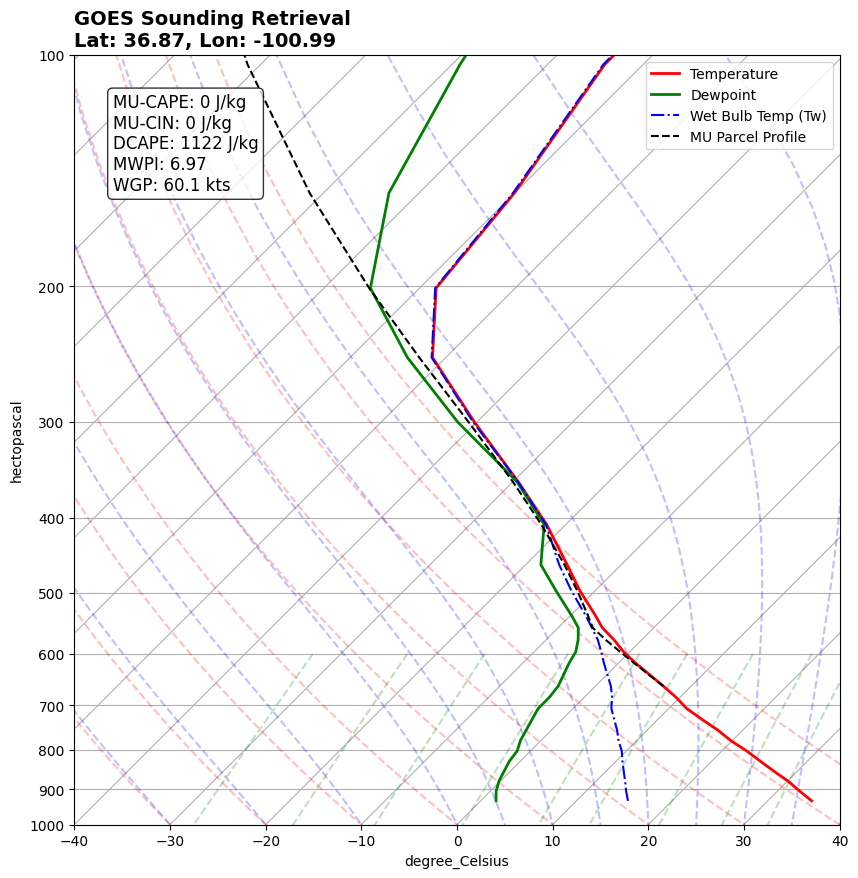

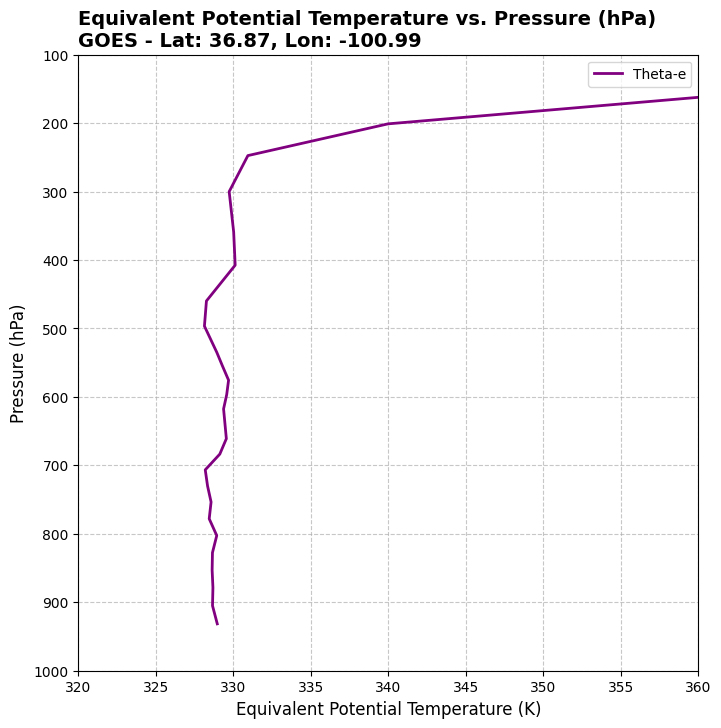

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

def get_standard_height_km(pressure_hpa):
    """
    Interpolates geometric height (km) for a given pressure array 
    based on the 1976 US Standard Atmosphere Table.
    """
    # Standard Atmosphere Table (Z in km, P in hPa)
    std_z = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28, 30])
    std_p = np.array([1013.25, 898.76, 795.01, 701.21, 616.60, 540.48, 472.17, 411.05, 356.51, 308.00, 264.99, 
                      227.00, 193.99, 165.79, 141.70, 121.11, 103.52, 88.49, 75.65, 64.67, 55.29, 40.47, 29.71, 
                      21.88, 16.16, 11.97])
    
    # np.interp expects x-coordinates to be monotonically increasing.
    # We use the natural log of pressure and reverse the arrays.
    log_p = np.log(std_p[::-1])
    z_rev = std_z[::-1]
    
    log_target_p = np.log(pressure_hpa)
    height_km = np.interp(log_target_p, log_p, z_rev)
    return height_km

def calculate_dcape(p, T, Td):
    """Calculates DCAPE (Downdraft CAPE) by finding min Theta-e."""
    try:
        theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
        
        sfc_p = p[0]
        search_layer_mask = p >= (sfc_p - 400 * units.hPa)
        min_thetae_idx = np.argmin(theta_e[search_layer_mask])
        
        p_origin = p[search_layer_mask][min_thetae_idx]
        T_origin = T[search_layer_mask][min_thetae_idx]
        Td_origin = Td[search_layer_mask][min_thetae_idx]
        
        wb_origin = mpcalc.wet_bulb_temperature(p_origin, T_origin, Td_origin)
        descending_p = p[p >= p_origin]
        
        downdraft_profile = mpcalc.moist_lapse(descending_p, wb_origin, reference_pressure=p_origin)
        env_T = T[p >= p_origin]
        
        delta_p = np.abs(np.diff(descending_p.m)) * units.hPa
        T_diff = (env_T.to('kelvin') - downdraft_profile.to('kelvin'))[:-1]
        Rd = 287.058 * units('J / (kg * K)')
        
        dcape_integral = np.sum(Rd * T_diff * (delta_p / descending_p[:-1]))
        return np.max([0, dcape_integral.m]) * units('J/kg')
    except Exception as e:
        print(f"Error calculating DCAPE: {e}")
        return 0 * units('J/kg')

def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
    """Calculates the Microburst Windspeed Potential Index (MWPI) and Wind Gust Potential (WGP)."""
    gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
    print(f"Lapse rate = {gamma:.2f}")
    
    DD_upper = T_upper - TD_upper
    DD_lower = T_lower - TD_lower
    DDD = DD_lower - DD_upper
    
    MWPI_val = (CAPE/1000) + (gamma/5) + (DDD/5)
    WGP = (0.35435365777 * (MWPI_val**2)) + (1.2959855 * MWPI_val) + 33.8176788
    
    return MWPI_val, WGP

def plot_goes_json_sounding(file_path):
    print(f"Processing JSON Sounding: {file_path}")
    
    # 1. Read JSON Data
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Extract raw arrays
    p_raw = np.array(data['temp_pressures'], dtype=float)
    T_raw = np.array(data['temperatures'], dtype=float)
    Td_raw = np.array(data['dewpoints'], dtype=float)
    
    # CRITICAL FIX: Filter out -999 fill values for levels below the surface
    # T_raw > 0 ensures we don't pass mathematically impossible negative Kelvin to MetPy
    valid = (p_raw > 0) & (T_raw > 0) & (Td_raw > 0)
    
    # Apply mask and attach units
    p = p_raw[valid] * units.hPa
    T = (T_raw[valid] * units.K).to('degC')
    Td = (Td_raw[valid] * units.K).to('degC')
    
    sat_name = data.get('sat', 'GOES')
    lat_val = data.get('lat', 0.0)
    lon_val = data.get('lon', 0.0)
    
    # 2. Interpolate Geometric Height (km) array
    height_km = get_standard_height_km(p.m) * units.km
    
    # 3. Perform Thermodynamic Calculations
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
    mu_p, mu_t, mu_td, mu_idx = mpcalc.most_unstable_parcel(p, T, Td)
    parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')
    
    dcape = calculate_dcape(p, T, Td)
    Tw = mpcalc.wet_bulb_temperature(p, T, Td)
    theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
    
    # --- MWPI Calculation Setup ---
    p_m = p.m
    sort_idx = np.argsort(p_m)
    p_sorted = p_m[sort_idx]
    
    def log_interp_level(target_p, val_arr):
        return np.interp(np.log(target_p), np.log(p_sorted), val_arr[sort_idx])

    P_level_upper = max(500.0, p_sorted[0])
    P_level_lower = min(850.0, p_sorted[-1])
    
    T_upper = log_interp_level(P_level_upper, T.m)
    T_lower = log_interp_level(P_level_lower, T.m)
    TD_upper = log_interp_level(P_level_upper, Td.m)
    TD_lower = log_interp_level(P_level_lower, Td.m)
    
    Z_upper = log_interp_level(P_level_upper, height_km.m)
    Z_lower = log_interp_level(P_level_lower, height_km.m)
    
    mwpi_val, wgp_val = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, 
                             T_upper, T_lower, TD_upper, TD_lower, mucape.m)

    # ==========================================
    # FIGURE 1: SKEW-T LOG-P DIAGRAM
    # ==========================================
    fig1 = plt.figure(figsize=(10, 10))
    skew = SkewT(fig1, rotation=45)
    
    # Plot environmental profiles (Including Tw)
    skew.plot(p, T, 'r', linewidth=2, label='Temperature')
    skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')
    skew.plot(p, Tw, 'b', linestyle='-.', linewidth=1.5, label='Wet Bulb Temp (Tw)')
    
    # Plot Parcel Path and Shade
    skew.plot(p[mu_idx:], parcel_prof, 'k', linestyle='--', linewidth=1.5, label='MU Parcel Profile')
    skew.shade_cape(p[mu_idx:], T[mu_idx:], parcel_prof)
    skew.shade_cin(p[mu_idx:], T[mu_idx:], parcel_prof, Td[mu_idx:])
    
    # Standard Skew-T background lines
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    
    skew.ax.set_ylim(1000, 100)
    skew.ax.set_xlim(-40, 40)
    
    plt.title(f'{sat_name} Sounding Retrieval\nLat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
              fontsize=14, fontweight='bold', loc='left')
    
    param_text = f"MU-CAPE: {mucape:~P.0f}\nMU-CIN: {mucin:~P.0f}\nDCAPE: {dcape:~P.0f}\nMWPI: {mwpi_val:.2f}\nWGP: {wgp_val:.1f} kts"
    skew.ax.text(0.05, 0.95, param_text, transform=skew.ax.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    skew.ax.legend(loc='upper right')
    
    output_filename1 = file_path.replace('.json', '_SkewT.png')
    plt.savefig(output_filename1, bbox_inches='tight', dpi=150)
    print(f"Skew-T Plot saved successfully as {output_filename1}")
    
    # ==========================================
    # FIGURE 2: THETA-E VS PRESSURE DIAGRAM
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.plot(theta_e, p, color='purple', linewidth=2, label='Theta-e')
    
    ax2.set_ylim(1000, 100)
    ax2.set_yscale('linear') 
    ax2.set_xlim(320, 360)
    
    ax2.set_xlabel('Equivalent Potential Temperature (K)', fontsize=12)
    ax2.set_ylabel('Pressure (hPa)', fontsize=12)
    ax2.set_title(f'Equivalent Potential Temperature vs. Pressure (hPa)\n{sat_name} - Lat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
                  fontsize=14, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')
    
    output_filename2 = file_path.replace('.json', '_ThetaE.png')
    plt.savefig(output_filename2, bbox_inches='tight', dpi=150)
    print(f"Theta-E Profile saved successfully as {output_filename2}")
    
    plt.show()

if __name__ == "__main__":
    file_name = "GOES_1778785200_3687-10099.json"
    plot_goes_json_sounding(file_name)